Multi-Path Shortest Path using QUBO

This notebook formulates the shortest path problem as a Quadratic Unconstrained Binary Optimization (QUBO) model.

We extend the formulation to handle multiple paths with:
- Flow constraints
- Degree constraints
- Shared edge penalties

The solution is obtained using brute-force search.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from importlib import reload
import qubo_utils
reload(qubo_utils)

<module 'qubo_utils' from 'c:\\Users\\Usaid\\qubo\\qubo_utils.py'>

In [2]:
import importlib
import qubo_utils

importlib.reload(qubo_utils)

<module 'qubo_utils' from 'c:\\Users\\Usaid\\qubo\\qubo_utils.py'>

In [3]:
from qubo_utils import build_multi_Q_strict

Solver Utility Functions

In [4]:
import itertools
import numpy as np


def check_validity(bits, edges, nodes, targets):
    active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

    if not active_edges:
        return False

    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)

        if (out_degree - in_degree) != targets[v]:
            return False

    return True


def get_path_string(bits, edge_names):
    chosen = [
        edge_names[i]
        for i in range(len(edge_names))
        if bits[i] == 1
    ]
    return " -> ".join(chosen) if chosen else "No Path"


def brute_force(Q, costs, edges, nodes, targets):
    num_vars = Q.shape[0]

    valid_results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        if check_validity(bits, edges, nodes, targets):

            path_cost = sum(
                costs[i]
                for i in range(len(edges))
                if bits[i] == 1
            )

            valid_results.append({
                "bits": bits,
                "energy": energy,
                "path_cost": path_cost
            })

    best = min(valid_results, key=lambda r: r["energy"])

    return best

In [5]:
import matplotlib.pyplot as plt
import itertools
import numpy as np


def make_plot(Q, costs, edges, nodes, targets):
    num_vars = Q.shape[0]

    results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        valid = check_validity(bits, edges, nodes, targets)

        path_cost = sum(
            costs[i]
            for i in range(len(edges))
            if bits[i] == 1
        )

        results.append({
            "energy": energy,
            "valid": valid,
            "path_cost": path_cost
        })
    # extract energies 
    energies = [r["energy"] for r in results]

    min_energy = min(energies)
    for r in results:
        r["energy"] = r["energy"] - min_energy


    valid_results = [r for r in results if r["valid"]]
    best = min(valid_results, key=lambda r: r["energy"])

    x_vals = [r["path_cost"] for r in results]
    y_vals = [r["energy"] for r in results]
    colors = ["green" if r["valid"] else "lightcoral" for r in results]

    plt.figure(figsize=(10,6))
    # invalid first (background)
    invalid_x = [r["path_cost"] for r in results if not r["valid"]]
    invalid_y = [r["energy"] for r in results if not r["valid"]]

    valid_x = [r["path_cost"] for r in results if r["valid"]]
    valid_y = [r["energy"] for r in results if r["valid"]]

    plt.scatter(invalid_x, invalid_y, c="lightcoral", s=30, alpha=0.5, label="Invalid")
    plt.scatter(valid_x, valid_y, c="green", s=70, marker='x', label="Valid")
    plt.scatter(best["path_cost"], best ["energy"],
                s=300, edgecolors='black', facecolors='yellow', linewidths=2,
                marker='o', zorder=10, label="Best Solution")
    plt.annotate("Best", (best["path_cost"], best["energy"]), textcoords="offset points", xytext=(10, 12), fontsize=10, color="black", weight="bold")
    plt.title("Energy vs Path Cost")
    plt.xlabel("Path Cost")
    plt.ylabel("Energy")
    plt.grid(True, alpha=0.3)
    plt.axhline(best["energy"], linestyle="--", color="blue", linewidth=2, alpha=0.7, label="Min Valid Energy")
    plt.ylim(-2, max(y_vals)*1.1)
    plt.legend()
    plt.show()

In [6]:
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
costs = [2.5, 5.0, 1.0, 3.0, 1.5]
nodes = [0,1,2,3]
targets = {0:1, 1:0, 2:0, 3:-1}

Q = qubo_utils.build_Q(costs, edges, nodes, targets)
print(Q)

[[ 2.5  6.  -6.  -6.   0. ]
 [ 0.   5.   6.   0.  -6. ]
 [ 0.   0.   7.   6.  -6. ]
 [ 0.   0.   0.   3.   6. ]
 [ 0.   0.   0.   0.   1.5]]


--- VALIDATION RESULTS ---
Lowest VALID Energy: -1.0
Best Configuration: (1, 0, 1, 0, 1)
Human Readable Path: AB -> BC -> CD
Path Length: 5.0


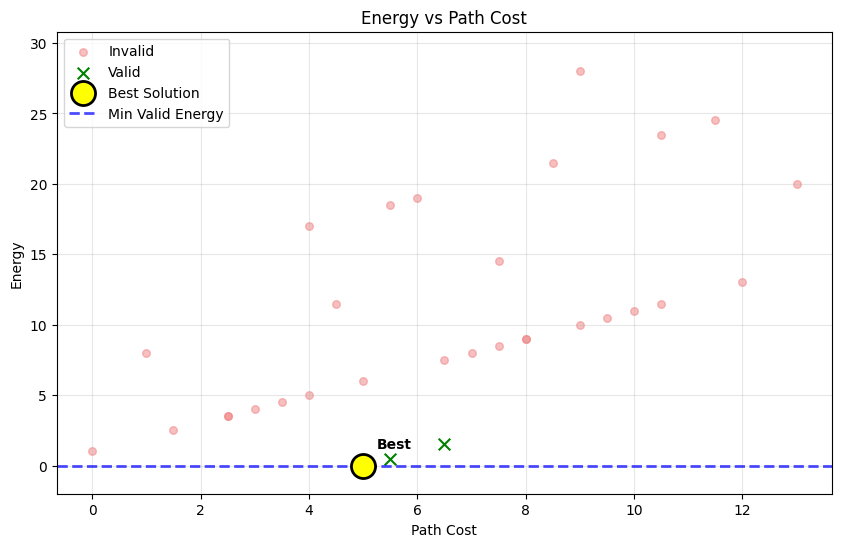

In [7]:
import matplotlib.pyplot as plt
import itertools
import numpy as np

# --- SETUP GRAPH ---
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
edge_names = ["AB", "AC", "BC", "BD", "CD"]

costs = [2.5, 5.0, 1.0, 3.0, 1.5]

nodes = [0,1,2,3]

targets = {0:1, 1:0, 2:0, 3:-1}

# Build QUBO
Q = qubo_utils.build_Q(costs, edges, nodes, targets)

# Solve
best = brute_force(Q, costs, edges, nodes, targets)

# Output
print("--- VALIDATION RESULTS ---")
print("Lowest VALID Energy:", best["energy"])
print("Best Configuration:", best["bits"])
print("Human Readable Path:", get_path_string(best["bits"], edge_names))
print("Path Length:", best["path_cost"])

make_plot(Q, costs, edges, nodes, targets)


In [8]:
import random

def classical_shortest_path(costs):
    candidates = [
        costs[0] + costs[3],                 # AB -> BD
        costs[1] + costs[4],                 # AC -> CD
        costs[0] + costs[2] + costs[4]      # AB -> BC -> CD
    ]
    return min(candidates)


def test_run():
    edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
    edge_names = ["AB","AC","BC","BD","CD"]
    nodes = [0,1,2,3]
    targets = {0:1,1:0,2:0,3:-1}

    costs = [random.randint(1,9) for _ in range(5)]

    Q = qubo_utils.build_Q(costs, edges, nodes, targets)

    best = brute_force(Q, costs, edges, nodes, targets)

    qubo_cost = best["path_cost"]
    classical_cost = classical_shortest_path(costs)

    status = "PASS" if qubo_cost == classical_cost else "FAIL"

    print("Costs:", costs)
    print("QUBO Cost:", qubo_cost)
    print("Classical Cost:", classical_cost)
    print("Result:", status)

## Larger Graph Test (5 Nodes)
Testing generalized build_Q() on a bigger graph.

In [9]:
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = qubo_utils.build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(7, 7)
[[ 2.  6. -6. -6.  0.  0.  0.]
 [ 0.  4.  6.  0. -6. -6.  0.]
 [ 0.  0.  7.  6. -6. -6.  0.]
 [ 0.  0.  0.  9.  6.  0. -6.]
 [ 0.  0.  0.  0.  8.  6. -6.]
 [ 0.  0.  0.  0.  0.  5.  6.]
 [ 0.  0.  0.  0.  0.  0.  1.]]


Verify solver still finds correct shortest valid path on larger graph.

In [10]:
import itertools
import numpy as np

num_vars = Q.shape[0]

def check_validity(bits, edges, nodes, targets):
    active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

    if not active_edges:
        return False

    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)

        if (out_degree - in_degree) != targets[v]:
            return False

    return True


def get_path_string(bits, edge_names):
    chosen = [
        edge_names[i]
        for i in range(len(edge_names))
        if bits[i] == 1
    ]
    return " -> ".join(chosen) if chosen else "No Path"


results = []

for bits in itertools.product([0,1], repeat=num_vars):
    x = np.array(bits)

    energy = x.T @ Q @ x
    valid = check_validity(bits, edges, nodes, targets)

    path_cost = sum(costs[i] for i in range(len(edges)) if bits[i] == 1)

    results.append((bits, energy, valid, path_cost))

valid_results = [r for r in results if r[2]]

best = min(valid_results, key=lambda x: x[1])

print("Lowest VALID Energy:", best[1])
print("Best Configuration:", best[0])
print("Chosen Path:", get_path_string(best[0], edge_names))
print("Path Cost:", best[3])

Lowest VALID Energy: 0.0
Best Configuration: (1, 0, 0, 1, 0, 0, 1)
Chosen Path: 01 -> 13 -> 34
Path Cost: 6


Batch Validation with Random Edge Weights

In [11]:
import random
import itertools
import numpy as np

# fixed graph structure
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]
nodes = [0,1,2,3,4]

targets = {0:1, 1:0, 2:0, 3:0, 4:-1}


def classical_paths(costs):
    candidates = {
        "01->13->34": costs[0] + costs[3] + costs[6],
        "02->24": costs[1] + costs[5],
        "01->12->24": costs[0] + costs[2] + costs[5],
        "01->12->23->34": costs[0] + costs[2] + costs[4] + costs[6],
        "02->23->34": costs[1] + costs[4] + costs[6],
    }
    return min(candidates.values())


for test in range(10):

    costs = [random.randint(1,9) for _ in range(len(edges))]

    Q = qubo_utils.build_Q(costs, edges, nodes, targets)

    num_vars = Q.shape[0]

    results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

        valid = True
        if not active_edges:
            valid = False

        for v in nodes:
            indeg = sum(1 for u,w in active_edges if w == v)
            outdeg = sum(1 for u,w in active_edges if u == v)

            if outdeg - indeg != targets[v]:
                valid = False

        if valid:
            path_cost = sum(costs[i] for i in range(len(edges)) if bits[i] == 1)
            results.append((energy, path_cost))

    best = min(results, key=lambda x: x[0])

    qubo_cost = best[1]
    classical_cost = classical_paths(costs)

    status = "PASS" if qubo_cost == classical_cost else "FAIL"

    print(f"Test {test+1}: costs={costs} | QUBO={qubo_cost} | Classical={classical_cost} --> {status}")

Test 1: costs=[6, 6, 7, 6, 9, 2, 3] | QUBO=8 | Classical=8 --> PASS
Test 2: costs=[3, 4, 2, 9, 8, 8, 1] | QUBO=12 | Classical=12 --> PASS
Test 3: costs=[2, 9, 3, 8, 1, 2, 8] | QUBO=7 | Classical=7 --> PASS
Test 4: costs=[7, 6, 8, 1, 9, 9, 3] | QUBO=11 | Classical=11 --> PASS
Test 5: costs=[8, 7, 5, 2, 6, 1, 2] | QUBO=8 | Classical=8 --> PASS
Test 6: costs=[5, 8, 4, 8, 8, 7, 1] | QUBO=14 | Classical=14 --> PASS
Test 7: costs=[3, 3, 3, 2, 4, 8, 3] | QUBO=8 | Classical=8 --> PASS
Test 8: costs=[6, 5, 3, 5, 9, 8, 8] | QUBO=13 | Classical=13 --> PASS
Test 9: costs=[6, 1, 2, 8, 5, 8, 2] | QUBO=8 | Classical=8 --> PASS
Test 10: costs=[5, 6, 7, 1, 6, 8, 9] | QUBO=14 | Classical=14 --> PASS


Two Simultaneous Paths Prototype

In [12]:
Q_single = qubo_utils.build_Q(costs, edges, nodes, targets)

n = Q_single.shape[0]
m = len(edges)          # number of real edge variables only

Q_two = np.zeros((2*n, 2*n))

# route 1 block
Q_two[:n, :n] = Q_single

# route 2 block
Q_two[n:, n:] = Q_single

# shared-edge penalty
Pc = 50

for e in range(m):
    Q_two[e, n + e] += Pc

print(Q_two.shape)
print(Q_two)

(14, 14)
[[ 5.  6. -6. -6.  0.  0.  0. 50.  0.  0.  0.  0.  0.  0.]
 [ 0.  6.  6.  0. -6. -6.  0.  0. 50.  0.  0.  0.  0.  0.]
 [ 0.  0. 13.  6. -6. -6.  0.  0.  0. 50.  0.  0.  0.  0.]
 [ 0.  0.  0.  7.  6.  0. -6.  0.  0.  0. 50.  0.  0.  0.]
 [ 0.  0.  0.  0. 12.  6. -6.  0.  0.  0.  0. 50.  0.  0.]
 [ 0.  0.  0.  0.  0.  8.  6.  0.  0.  0.  0.  0. 50.  0.]
 [ 0.  0.  0.  0.  0.  0.  9.  0.  0.  0.  0.  0.  0. 50.]
 [ 0.  0.  0.  0.  0.  0.  0.  5.  6. -6. -6.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  6.  6.  0. -6. -6.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 13.  6. -6. -6.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  7.  6.  0. -6.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 12.  6. -6.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  8.  6.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  9.]]


In [13]:
print("Populated QUBO Matrix Q:\n", Q)

Populated QUBO Matrix Q:
 [[ 5.  6. -6. -6.  0.  0.  0.]
 [ 0.  6.  6.  0. -6. -6.  0.]
 [ 0.  0. 13.  6. -6. -6.  0.]
 [ 0.  0.  0.  7.  6.  0. -6.]
 [ 0.  0.  0.  0. 12.  6. -6.]
 [ 0.  0.  0.  0.  0.  8.  6.]
 [ 0.  0.  0.  0.  0.  0.  9.]]


In [14]:
import random

print("Running robustness test with random edge costs...\n")

for i in range(5):
    random_costs = [round(random.uniform(1, 10), 1) for _ in range(5)]

    shortest_path = min(random_costs[0] + random_costs[3],   # AB + BD
                        random_costs[1] + random_costs[4],   # AC + CD
                        random_costs[0] + random_costs[2] + random_costs[4]) # AB+BC+CD

    print(f"Test {i+1}: Costs = {random_costs}")
    print(f"Expected shortest path length = {shortest_path}")
    print("-" * 40) 

Running robustness test with random edge costs...

Test 1: Costs = [6.2, 5.0, 9.4, 1.8, 5.4]
Expected shortest path length = 8.0
----------------------------------------
Test 2: Costs = [1.5, 7.9, 3.4, 3.9, 3.5]
Expected shortest path length = 5.4
----------------------------------------
Test 3: Costs = [2.6, 4.6, 1.2, 5.8, 2.7]
Expected shortest path length = 6.5
----------------------------------------
Test 4: Costs = [8.8, 3.8, 7.8, 4.0, 8.5]
Expected shortest path length = 12.3
----------------------------------------
Test 5: Costs = [4.5, 3.7, 4.5, 4.3, 1.6]
Expected shortest path length = 5.300000000000001
----------------------------------------


Below we are using different random weights 

In [15]:
import numpy as np
import itertools
import random

def run_stress_test_with_flow(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        
        # 2. Re-build the Q Matrix from scratch for these weights
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                for j, s_vj in conn:
                    if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj

        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_stress_test_with_flow(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: VALID | Path: AC -> CD | Energy: -26.5 | Weights: [7.48, 9.82, 4.67, 6.97, 3.66]
Run 2: VALID | Path: AB -> BD | Energy: -28.1 | Weights: [9.46, 7.41, 1.74, 2.47, 8.82]
Run 3: VALID | Path: AC -> CD | Energy: -27.1 | Weights: [9.54, 9.91, 1.15, 9.9, 2.97]
Run 4: VALID | Path: AC -> CD | Energy: -22.9 | Weights: [8.85, 9.26, 2.76, 9.68, 7.88]
Run 5: VALID | Path: AC -> CD | Energy: -30.5 | Weights: [9.93, 1.15, 1.42, 8.86, 8.3]
Run 6: VALID | Path: AC -> CD | Energy: -31.7 | Weights: [7.36, 6.27, 7.1, 7.21, 2.05]
Run 7: VALID | Path: AB -> BD | Energy: -28.9 | Weights: [1.3, 7.8, 7.01, 9.76, 8.67]
Run 8: VALID | Path: AC -> CD | Energy: -27.5 | Weights: [9.98, 8.24, 1.84, 7.06, 4.22]
Run 9: VALID | Path: AB -> BD | Energy: -31.6 | Weights: [5.77, 3.01, 1.92, 2.63, 6.8]
Run 10: VALID | Path: AB -> BD | Energy: -25.9 | Weights: [9.95, 6.57, 9.49, 4.19, 8.46]

--- TEST COMPLETE ---
Final Reliability: 100.0%


Accordiing to the results we got above it proves that even though the weights chaged every single time it always found a valid path

In the code below we have removed the flow term ( That part is commented out) and ran the code with 5 random values for edges.

In [16]:
import numpy as np
import itertools
import random

def run_stress_test_without_flow(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        """ 
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                #Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                #for j, s_vj in conn:
                    #if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj
        """
        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_stress_test_without_flow(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: INVALID | Weights: [2.72, 8.5, 8.29, 6.97, 9.31]
Run 2: INVALID | Weights: [4.95, 6.71, 4.26, 6.9, 3.11]
Run 3: INVALID | Weights: [1.47, 9.73, 4.47, 2.37, 9.54]
Run 4: INVALID | Weights: [8.76, 7.53, 5.87, 2.87, 5.29]
Run 5: INVALID | Weights: [1.19, 7.74, 2.25, 3.1, 7.63]
Run 6: INVALID | Weights: [9.39, 4.87, 2.54, 1.12, 1.58]
Run 7: INVALID | Weights: [7.83, 5.12, 8.07, 7.64, 8.55]
Run 8: INVALID | Weights: [6.14, 3.02, 6.12, 5.64, 6.92]
Run 9: INVALID | Weights: [7.22, 8.03, 1.4, 6.79, 4.62]
Run 10: INVALID | Weights: [9.47, 3.21, 6.49, 4.53, 1.63]

--- TEST COMPLETE ---
Final Reliability: 0.0%


So according to the results we got above it shows that without the flow term the program picks NO edges because that gives the lowest energy. Selecting a valid path costs some energy, so program chooses an invalid path that gives 0 energy which is always selecting no edge at all (0,0,0,0,0,0,0).And our validity checker gives always answer as "invalid" because it violates our requirements 

When the flow term is available ;If A acts as a source (+1 flow) and D acts as a sink (-1 flow), that penalty becomes 0.And if Node A doesn't have an outgoing edge and Node D doesn't have an incoming edge ,energy gets increased by 20.



In [17]:
test_run()

Costs: [7, 1, 1, 5, 9]
QUBO Cost: 10
Classical Cost: 10
Result: PASS


Multipath Prototype

In [18]:
# Two required source-target pairs
path_targets = [(0,3), (1,4)]

print("Required Paths:")
for i, (s, t) in enumerate(path_targets, 1):
    print(f"Path {i}: {s} -> {t}")

Required Paths:
Path 1: 0 -> 3
Path 2: 1 -> 4


In [19]:
# Example graph with 6 edges
edges = [(0,1), (0,2), (1,3), (2,3), (1,4), (2,4)]

num_edges = len(edges)
num_paths = len(path_targets)

# one binary block per path
total_variables = num_edges * num_paths

print("Edges:", edges)
print("Edges per path:", num_edges)
print("Number of paths:", num_paths)
print("Total binary variables:", total_variables)

Edges: [(0, 1), (0, 2), (1, 3), (2, 3), (1, 4), (2, 4)]
Edges per path: 6
Number of paths: 2
Total binary variables: 12


In [20]:
print("Variable Index Map")

for p in range(num_paths):
    print(f"\nPath {p+1} variables:")

    for e in range(num_edges):
        var_index = p * num_edges + e
        print(f"x[{var_index}] = Path {p+1}, Edge {edges[e]}")

Variable Index Map

Path 1 variables:
x[0] = Path 1, Edge (0, 1)
x[1] = Path 1, Edge (0, 2)
x[2] = Path 1, Edge (1, 3)
x[3] = Path 1, Edge (2, 3)
x[4] = Path 1, Edge (1, 4)
x[5] = Path 1, Edge (2, 4)

Path 2 variables:
x[6] = Path 2, Edge (0, 1)
x[7] = Path 2, Edge (0, 2)
x[8] = Path 2, Edge (1, 3)
x[9] = Path 2, Edge (2, 3)
x[10] = Path 2, Edge (1, 4)
x[11] = Path 2, Edge (2, 4)


In [21]:
import numpy as np

P_shared = 10

Q_multi = np.zeros((total_variables, total_variables))

# Penalize shared edge usage between paths
for e in range(num_edges):
    i = e                 # Path 1 variable
    j = num_edges + e     # Path 2 variable

    Q_multi[i, j] += P_shared

print("Multipath QUBO shape:", Q_multi.shape)
print(Q_multi)

Multipath QUBO shape: (12, 12)
[[ 0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 10.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]


In [22]:
for k, (source, sink) in enumerate(path_targets):

    print(f"\nPath {k+1}: {source} -> {sink}")

    for node in sorted(set(sum(edges, ()))):
        outgoing = [e for e, (u,v) in enumerate(edges) if u == node]
        incoming = [e for e, (u,v) in enumerate(edges) if v == node]

        if node == source:
            target_flow = 1
        elif node == sink:
            target_flow = -1
        else:
            target_flow = 0

        print(
            f"Node {node}: out={outgoing}, in={incoming}, target={target_flow}"
        )


Path 1: 0 -> 3
Node 0: out=[0, 1], in=[], target=1
Node 1: out=[2, 4], in=[0], target=0
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=-1
Node 4: out=[], in=[4, 5], target=0

Path 2: 1 -> 4
Node 0: out=[0, 1], in=[], target=0
Node 1: out=[2, 4], in=[0], target=1
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=0
Node 4: out=[], in=[4, 5], target=-1


In [23]:
def build_multi_Q(edges, path_targets, costs, P_shared=10, P_flow=20):
    import numpy as np

    num_edges = len(edges)
    num_paths = len(path_targets)

    total_variables = num_edges * num_paths
    Q = np.zeros((total_variables, total_variables))

    nodes = sorted(set(sum(edges, ())))

    # Edge costs
    for p in range(num_paths):
        for e in range(num_edges):
            idx = p * num_edges + e
            Q[idx, idx] += costs[e]

    # Shared-edge penalty
    for e in range(num_edges):
        for p1 in range(num_paths):
            for p2 in range(p1 + 1, num_paths):
                i = p1 * num_edges + e
                j = p2 * num_edges + e
                Q[i, j] += P_shared

    # Source / sink penalties
    for p, (source, sink) in enumerate(path_targets):

        for e, (u, v) in enumerate(edges):
            idx = p * num_edges + e

            # reward leaving source
            if u == source:
                Q[idx, idx] -= P_flow

            # reward entering sink
            if v == sink:
                Q[idx, idx] -= P_flow

    return Q

In [24]:
costs = [2,4,3,2,5,1]

Q_multi = build_multi_Q(edges, path_targets, costs)

print(Q_multi.shape)
print(Q_multi)

(12, 12)
[[-18.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.   0.]
 [  0. -16.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.]
 [  0.   0. -17.   0.   0.   0.   0.   0.  10.   0.   0.   0.]
 [  0.   0.   0. -18.   0.   0.   0.   0.   0.  10.   0.   0.]
 [  0.   0.   0.   0.   5.   0.   0.   0.   0.   0.  10.   0.]
 [  0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  10.]
 [  0.   0.   0.   0.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   4.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0. -17.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   2.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -35.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -19.]]


# Brute-Force Optimization of the Multi-Path QUBO 

performs a classical brute-force search for all possible binary configuarations of the QUBO variables. 

- Best Energy -> minimum QUBO objective value
- Best Bitstring -> optimal binary configuration 

In [25]:
import itertools
import numpy as np

best_energy = float("inf")
best_bits = None

n = Q_multi.shape[0]

for bits in itertools.product([0,1], repeat=n):
    x = np.array(bits)
    energy = x.T @ Q_multi @ x

    if energy < best_energy:
        best_energy = energy
        best_bits = bits

print("Best Energy:", best_energy)
print("Best Bitstring:", best_bits)

Best Energy: -130.0
Best Bitstring: (1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1)


# Decoding the Optimal QUBO Solution into Paths

In [26]:
num_edges = len(edges)

for p in range(len(path_targets)):
    print(f"\nPath {p+1}")

    for e in range(num_edges):
        idx = p * num_edges + e

        if best_bits[idx] == 1: #if bit is active (1) the corresponding edge is part of the selected path
            print("Uses edge:", edges[e])


Path 1
Uses edge: (0, 1)
Uses edge: (0, 2)
Uses edge: (1, 3)
Uses edge: (2, 3)

Path 2
Uses edge: (1, 3)
Uses edge: (1, 4)
Uses edge: (2, 4)


In [27]:
# -----------------------------
# MULTI-PATH VALIDATION
# -----------------------------

num_edges = len(edges)

# Split bitstring into path blocks
path1_bits = best_bits[:num_edges]
path2_bits = best_bits[num_edges:]

print("\n--- PATH VALIDATION ---")

print("Path 1 bits:", path1_bits)
print("Path 2 bits:", path2_bits)

# Decode active edges
def decode_path(bits, edges):
    active = []

    for i, b in enumerate(bits):
        if b == 1:
            active.append(edges[i])

    return active

path1_edges = decode_path(path1_bits, edges)
path2_edges = decode_path(path2_bits, edges)

print("\nPath 1 active edges:")
print(path1_edges)

print("\nPath 2 active edges:")
print(path2_edges)


--- PATH VALIDATION ---
Path 1 bits: (1, 1, 1, 1, 0, 0)
Path 2 bits: (0, 0, 1, 0, 1, 1)

Path 1 active edges:
[(0, 1), (0, 2), (1, 3), (2, 3)]

Path 2 active edges:
[(1, 3), (1, 4), (2, 4)]


In [ ]:
# -----------------------------
# HUMAN READABLE PATHS
# -----------------------------

edge_names = {
    (0,1): "AB",
    (0,2): "AC",
    (1,2): "BC",
    (1,3): "BD",
    (2,3): "CD",
    (2,4): "CE"
}

def readable_path(edge_list):
    names = []

    for e in edge_list:
        if e in edge_names:
            names.append(edge_names[e])
        else:
            names.append(str(e))

    return " -> ".join(names)



num_edges = len(edges)

path1_bits = best_bits[:num_edges]
path2_bits = best_bits[num_edges:]

path1_edges = [edges[i] for i, b in enumerate(path1_bits) if b == 1]
path2_edges = [edges[i] for i, b in enumerate(path2_bits) if b == 1]


print("\n--- HUMAN READABLE PATHS ---")

print("Path 1:")
print(readable_path(path1_edges))

print("\nPath 2:")
print(readable_path(path2_edges))


--- HUMAN READABLE PATHS ---
Path 1:
AB -> AC -> BD -> CD

Path 2:
BD -> (1, 4) -> CE


# Visualizing Flow-Conservation Requirement for Each Path

This helper function displays the flow requirements used to construct the QUBO contraints for each requested path. 

In [29]:
def show_path_flow_requirements(edges, path_targets):
    nodes = sorted(set(sum(edges, ())))

    for k, (source, sink) in enumerate(path_targets):
        print(f"\nPath {k+1}: {source} -> {sink}")

        for node in nodes:
            if node == source:
                target = 1
            elif node == sink:
                target = -1
            else:
                target = 0

            outgoing = [i for i, (u,v) in enumerate(edges) if u == node]
            incoming = [i for i, (u,v) in enumerate(edges) if v == node]

            print(
                f"Node {node}: out={outgoing}, in={incoming}, target={target}"
            )

In [30]:
show_path_flow_requirements(edges, path_targets)


Path 1: 0 -> 3
Node 0: out=[0, 1], in=[], target=1
Node 1: out=[2, 4], in=[0], target=0
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=-1
Node 4: out=[], in=[4, 5], target=0

Path 2: 1 -> 4
Node 0: out=[0, 1], in=[], target=0
Node 1: out=[2, 4], in=[0], target=1
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=0
Node 4: out=[], in=[4, 5], target=-1


# Path Target Definitions 

In [31]:
path_targets = [
    {0:1, 1:0, 2:0, 3:-1, 4:0},   # Path 1: 0 → 3
    {0:0, 1:1, 2:0, 3:0, 4:-1}    # Path 2: 1 → 4
]

Constructing the Multi-Path QUBO Matrix

In [32]:
costs = [2,4,3,2,5,1]

Q_multi = qubo_utils.build_multi_Q_strict(costs, edges, nodes, path_targets)

print(Q_multi.shape)

(12, 12)


->Searches all binary states
->Computes QUBO Energy
->Finds optimal bitstring

In [33]:
import itertools
import numpy as np

best_energy = float("inf")
best_bits = None

n = Q_multi.shape[0]

for bits in itertools.product([0,1], repeat=n):
    x = np.array(bits)
    energy = x.T @ Q_multi @ x

    if energy < best_energy:
        best_energy = energy
        best_bits = bits

print("Best Energy:", best_energy)
print("Best Bitstring:", best_bits)

Best Energy: -430.0
Best Bitstring: (1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0)


-> Decode solution into Paths

In [34]:
num_edges = len(edges)
block_size = Q_multi.shape[0] // len(path_targets)

for p in range(len(path_targets)):
    print(f"\nPath {p+1}")

    for e in range(num_edges):
        idx = p * block_size + e

        if best_bits[idx] == 1:
            print("Uses edge:", edges[e])


Path 1
Uses edge: (0, 1)
Uses edge: (1, 3)

Path 2
Uses edge: (1, 4)


-> Computing the cost of decoded path

In [35]:
for p in range(len(path_targets)):
    cost = 0
    print(f"\nPath {p+1} cost:")

    for e in range(num_edges):
        idx = p * block_size + e

        if best_bits[idx] == 1:
            print(edges[e], "cost =", costs[e])
            cost += costs[e]

    print("Total:", cost)


Path 1 cost:
(0, 1) cost = 2
(1, 3) cost = 3
Total: 5

Path 2 cost:
(1, 4) cost = 5
Total: 5


In [36]:
for _ in range(5):
    costs = np.random.randint(1,10,len(edges)).tolist()
    Q_multi = qubo_utils.build_multi_Q_strict(costs, edges, nodes, path_targets)

    # brute force again

In [37]:
from qubo_utils import *

print(build_multi_Q_strict)

<function build_multi_Q_strict at 0x000001269BA01EE0>
